# **DATA UNDERSTANDING**

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestClassifier
from tabulate import tabulate
import warnings

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)


## **Step 1: Load Data & Check Structure**

In [25]:
# Load the dataset
paysim_path = '../data/paysim.csv'
df = pd.read_csv(paysim_path)

In [26]:
# Display basic information
print("\nDataset Overview:")
print(tabulate(df.head(), headers="keys", tablefmt="pretty"))

print("\nDataset Info:")
df.info()

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")



Dataset Overview:
+---+------+----------+----------+-------------+---------------+----------------+-------------+----------------+----------------+---------+----------------+
|   | step |   type   |  amount  |  nameOrig   | oldbalanceOrg | newbalanceOrig |  nameDest   | oldbalanceDest | newbalanceDest | isFraud | isFlaggedFraud |
+---+------+----------+----------+-------------+---------------+----------------+-------------+----------------+----------------+---------+----------------+
| 0 |  1   | PAYMENT  | 9839.64  | C1231006815 |   170136.0    |   160296.36    | M1979787155 |      0.0       |      0.0       |    0    |       0        |
| 1 |  1   | PAYMENT  | 1864.28  | C1666544295 |    21249.0    |    19384.72    | M2044282225 |      0.0       |      0.0       |    0    |       0        |
| 2 |  1   | TRANSFER |  181.0   | C1305486145 |     181.0     |      0.0       | C553264065  |      0.0       |      0.0       |    1    |       0        |
| 3 |  1   | CASH_OUT |  181.0   | C840

This dataset contains 6,362,620 transaction records with 11 columns, including transaction type, amounts, origin and destination accounts, balances, and fraud labels.  

#### **Key Observations:**
- **No Missing Values:** The dataset is complete or clean.
- **Transaction Types:** Includes `PAYMENT`, `TRANSFER`, `CASH_OUT`, etc.
- **Fraud Cases:** `isFraud` (1 for fraud, 0 otherwise) has a very low mean (`0.00129`), indicating class imbalance.
- **Flagged Transactions:** `isFlaggedFraud` is extremely rare (`mean = 0.0000025`), meaning very few transactions are flagged.
- **Balance Changes:** Some destination accounts have zero balances before and after the transaction, which could indicate fraud tactics.

## **Step 2: Exploratory Data Analysis (EDA)**

In [27]:
# Summary statistics
print("\nSummary Statistics:")
print(tabulate(df.describe(), headers="keys", tablefmt="pretty"))

# Check class imbalance in the target variable
fraud_counts = df["isFraud"].value_counts()
print("\nFraud vs. Non-Fraud Counts:")
print(fraud_counts)

# Percentage of fraud cases
fraud_percentage = (fraud_counts[1] / df.shape[0]) * 100
print(f"\nPercentage of fraud cases: {fraud_percentage:.5f}%")

# Check unique transaction types
print("\nTransaction Types and Counts:")
print(df["type"].value_counts())

# Check outliers using Interquartile Range (IQR)
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

outlier_columns = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
for col in outlier_columns:
    outliers = detect_outliers(df, col)
    print(f"\nColumn: {col} | Outliers detected: {len(outliers)}")



Summary Statistics:
+-------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+-----------------------+
|       |        step        |       amount       |   oldbalanceOrg    |   newbalanceOrig   |   oldbalanceDest   |   newbalanceDest   |       isFraud        |    isFlaggedFraud     |
+-------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------------+-----------------------+
| count |     6362620.0      |     6362620.0      |     6362620.0      |     6362620.0      |     6362620.0      |     6362620.0      |      6362620.0       |       6362620.0       |
| mean  | 243.39724563151657 | 179861.90354913071 | 833883.1040744866  | 855113.6685785869  | 1100701.6665196486 | 1224996.3982019299 | 0.001290820448180152 | 2.51468734577894e-06  |
|  std  | 142.33197104914032 | 603858.2314629931  | 2888242.6730

#### **Key Observations from the Analysis**  

##### **1. Class Imbalance**  
- **Fraudulent transactions** are **extremely rare** (0.129% of the dataset).  
- The dataset is highly imbalanced, which may require **resampling techniques** (e.g., **SMOTE, undersampling**).  

##### **2. Transaction Types**  
- The most common transactions are **CASH_OUT and PAYMENT**.  
- **Fraud is more likely in TRANSFER and CASH_OUT transactions** (needs further verification).  

##### **3. Outliers in Transaction Amounts & Balances**  
- **A significant number of outliers** exist in financial features (e.g., **338,078 transactions have extreme amounts**).  
- Handling these outliers is crucial since fraud transactions could involve **unusually high or low amounts**.  
 

## **Step 3: Data Visualization**

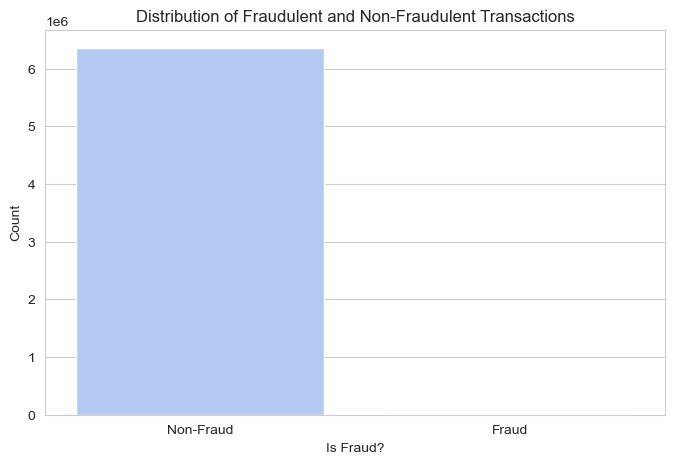

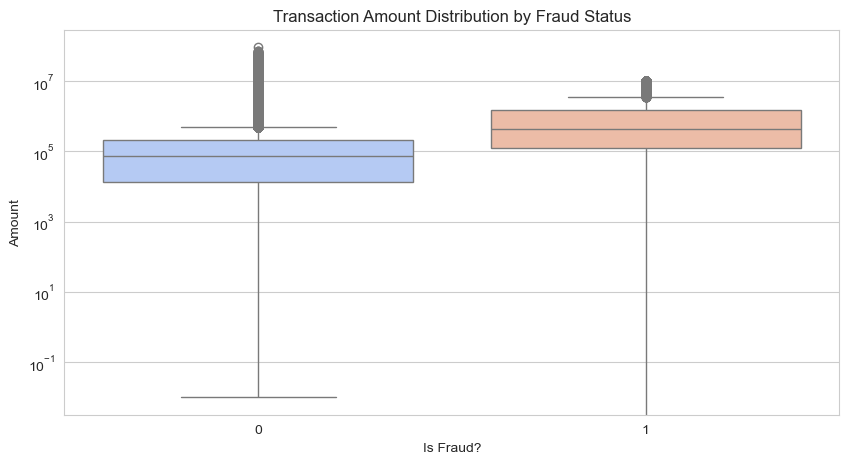

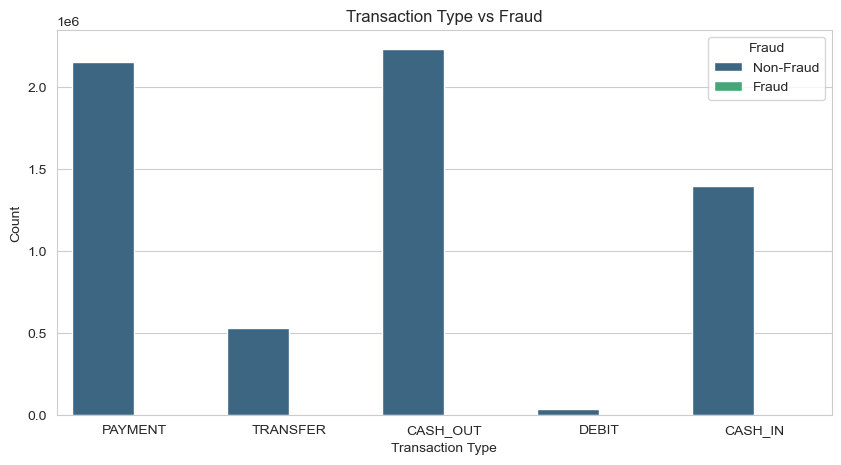

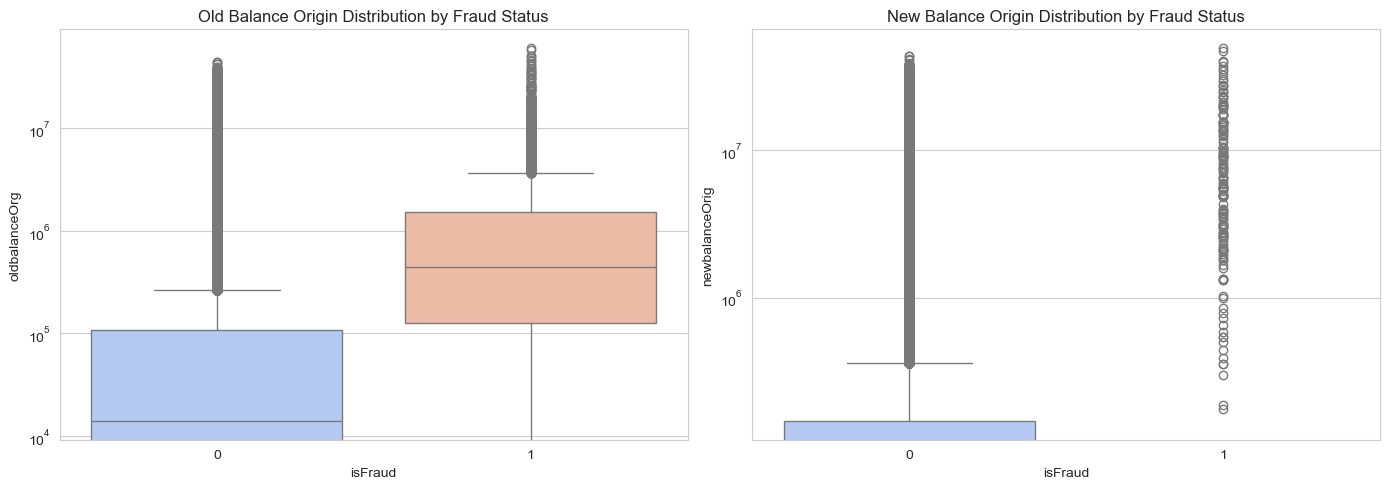

In [28]:
# Set visual style
sns.set_style("whitegrid")

# Fraud vs. Non-Fraud Transaction Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="isFraud", data=df, palette="coolwarm")
plt.title("Distribution of Fraudulent and Non-Fraudulent Transactions")
plt.xlabel("Is Fraud?")
plt.ylabel("Count")
plt.xticks([0, 1], labels=["Non-Fraud", "Fraud"])
plt.show()

# Transaction Amount Distribution
plt.figure(figsize=(10, 5))
sns.boxplot(x="isFraud", y="amount", data=df, palette="coolwarm")
plt.title("Transaction Amount Distribution by Fraud Status")
plt.xlabel("Is Fraud?")
plt.ylabel("Amount")
plt.yscale("log")  # Log scale to handle large transaction values
plt.show()

# Transaction Type vs. Fraud
plt.figure(figsize=(10, 5))
sns.countplot(x="type", hue="isFraud", data=df, palette="viridis")
plt.title("Transaction Type vs Fraud")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(title="Fraud", labels=["Non-Fraud", "Fraud"])
plt.show()

# Boxplots for balance distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="isFraud", y="oldbalanceOrg", data=df, ax=axes[0], palette="coolwarm")
axes[0].set_title("Old Balance Origin Distribution by Fraud Status")
axes[0].set_yscale("log")

sns.boxplot(x="isFraud", y="newbalanceOrig", data=df, ax=axes[1], palette="coolwarm")
axes[1].set_title("New Balance Origin Distribution by Fraud Status")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


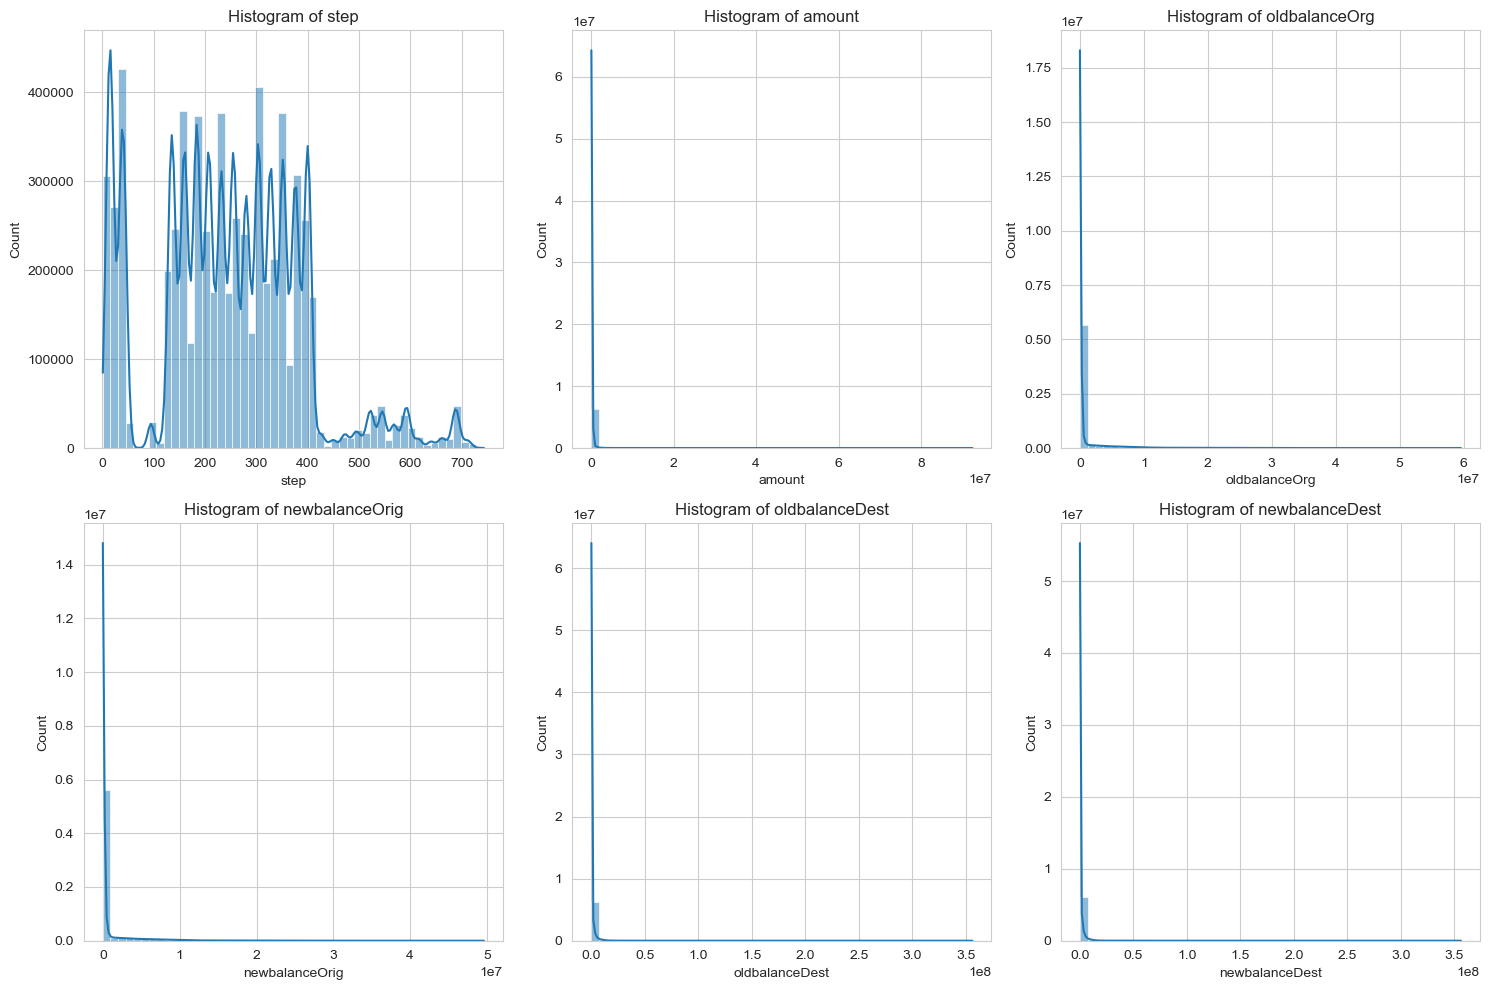

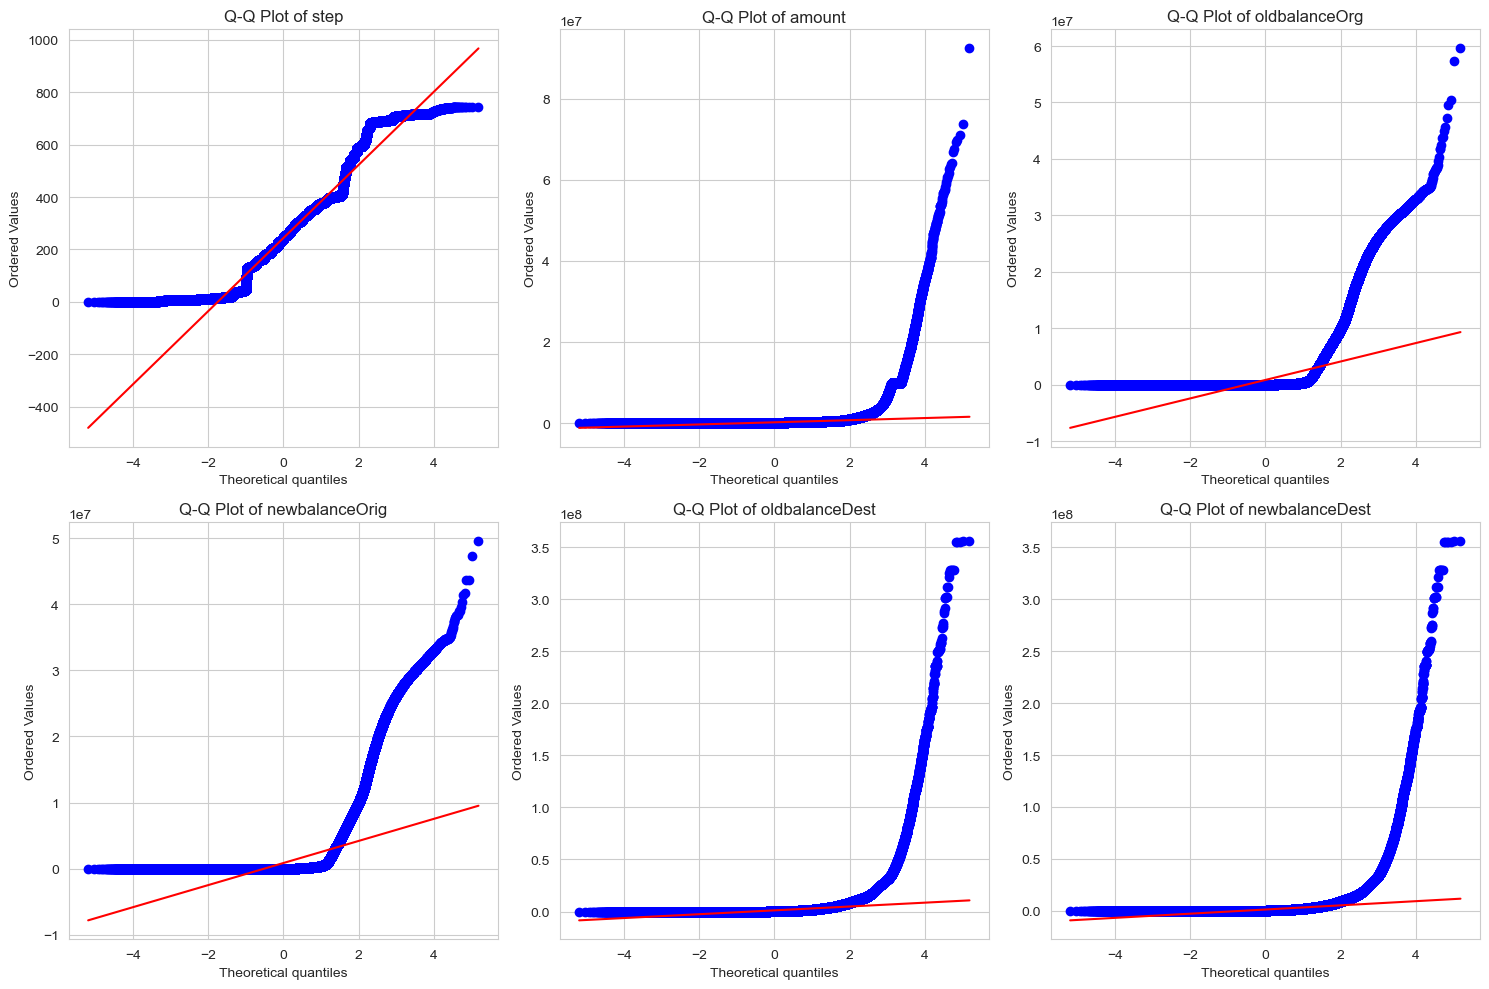


Distribution Summary:
          Feature   Skewness     Kurtosis
0            step   0.375177     0.329071
1          amount  30.993949  1797.956705
2   oldbalanceOrg   5.249136    32.964879
3  newbalanceOrig   5.176884    32.066985
4  oldbalanceDest  19.921758   948.674125
5  newbalanceDest  19.352302   862.156508


In [29]:
# Select numerical columns
num_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]

# Create histograms
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

# Create Q-Q plots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f"Q-Q Plot of {col}")
plt.tight_layout()
plt.show()

# Calculate skewness and kurtosis
distribution_summary = pd.DataFrame({
    "Feature": num_cols,
    "Skewness": [df[col].skew() for col in num_cols],
    "Kurtosis": [df[col].kurt() for col in num_cols]
})

# Display the skewness and kurtosis values
print("\nDistribution Summary:")
print(distribution_summary)


#### **Interpretation of Distribution Summary:**

1. **Step**
   - **Skewness: 0.375** (Slightly right-skewed, almost symmetric)
   - **Kurtosis: 0.329** (Light-tailed, fewer extreme values)
   - **Conclusion**: Fairly normal distribution with minor skewness.

2. **Amount**
   - **Skewness: 30.99** (Extremely right-skewed)
   - **Kurtosis: 1797.96** (Very heavy-tailed, lots of extreme values)
   - **Conclusion**: The amount has a highly skewed distribution with many extreme values (outliers).

3. **Old Balance (Origin)**
   - **Skewness: 5.25** (Right-skewed)
   - **Kurtosis: 32.96** (Heavy-tailed, presence of extreme values)
   - **Conclusion**: The old balance at the origin account is not normally distributed and contains large outliers.

4. **New Balance (Origin)**
   - **Skewness: 5.18** (Right-skewed)
   - **Kurtosis: 32.07** (Heavy-tailed)
   - **Conclusion**: Similar to `oldbalanceOrg`, this field also contains extreme values and is skewed.

5. **Old Balance (Destination)**
   - **Skewness: 19.92** (Highly right-skewed)
   - **Kurtosis: 948.67** (Extreme outliers present)
   - **Conclusion**: The balance at the destination is highly skewed and contains a significant number of extreme transactions.

6. **New Balance (Destination)**
   - **Skewness: 19.35** (Highly right-skewed)
   - **Kurtosis: 862.16** (Extreme outliers present)
   - **Conclusion**: Similar to `oldbalanceDest`, this column has significant outliers and a highly skewed distribution.

### **Key Takeaways:**
- **All financial variables (`amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) are highly skewed with heavy-tailed distributions.**  
- **"Step" is the only feature close to a normal distribution.**  
- **Presence of extreme outliers in financial fields suggests the need for outlier treatment before modeling.**  

# **Data Preparation**

## **Step 1: Outlier Detection & Transformations**
1. Anomaly Detection using Isolation Forest
2. Log transformation for highly skewed numerical features

In [30]:
# Define numerical features
num_features = [
    "amount", "oldbalanceOrg", "newbalanceOrig", 
    "oldbalanceDest", "newbalanceDest"
]

# Outlier Detection (Using Isolation Forest)
for feature in num_features:
    iso_forest = IsolationForest(contamination=0.01, random_state=42)
    df[f"{feature}_outlier"] = iso_forest.fit_predict(df[[feature]])

# Alternative: Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df["lof_outlier"] = lof.fit_predict(df[num_features])

# Log Transformation for Skewed Features
df["amount_log"] = np.log1p(df["amount"])

# Use RobustScaler Instead of StandardScaler
scaler = RobustScaler()
df[num_features] = scaler.fit_transform(df[num_features])

print("Outlier detection, transformation, and scaling complete!")


Outlier detection, transformation, and scaling complete!


## **Step 2: Handle Data Quality Issues**
1. Check for Data Leakage
2. Analyze isFlaggedFraud
3. Identify Potential Label Errors
4. Detect Irregularities in Transactions

In [31]:
# Identify potential leakage (e.g., post-transaction features)
leakage_features = [col for col in df.columns if 'flag' in col.lower() or 'fraud' in col.lower()]
print(f"Potential Leakage Features: {leakage_features}")

# Analyze isFlaggedFraud
flagged_fraud_corr = df[['isFraud', 'isFlaggedFraud']].corr()
print("\nCorrelation between Fraud and Flagged Transactions:")
print(flagged_fraud_corr)

# Identify label inconsistencies
fraud_transfers = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]
label_mismatches = fraud_transfers[(fraud_transfers['isFraud'] == 0) & (fraud_transfers['amount'] > 200000)]
print(f"\nPotential mislabeled fraud transactions: {len(label_mismatches)}")

# Check anomalies in amount distribution
df['amount_log'] = np.log1p(df['amount'])
df[['amount', 'amount_log']].describe()


Potential Leakage Features: ['isFraud', 'isFlaggedFraud']

Correlation between Fraud and Flagged Transactions:
                 isFraud  isFlaggedFraud
isFraud         1.000000        0.044109
isFlaggedFraud  0.044109        1.000000

Potential mislabeled fraud transactions: 0


,amount,amount_log
count,6.362620e+06,6.362620e+06
mean,5.374952e-01,1.453366e-01
std,3.091447e+00,6.121606e-01
min,-3.833062e-01,-4.833827e-01
25%,-3.147585e-01,-3.779839e-01
50%,0.000000e+00,-2.568501e-13
75%,6.852415e-01,5.219089e-01
max,4.728907e+02,6.160977e+00


## **Step 3: Feature Engineering for Fraud Detection**
1. Transaction Velocity Features
2. Rolling Amount Aggregations
3. Account Risk Features
4. Graph-Based Features

In [ ]:
# Transaction Velocity Features
df['hourly_txn_count'] = df.groupby('nameOrig')['step'].transform(lambda x: x.rolling(window=6, min_periods=1).count())
df['daily_txn_count'] = df.groupby('nameOrig')['step'].transform(lambda x: x.rolling(window=24, min_periods=1).count())

# Rolling Amount Features
df['hourly_amount_sum'] = df.groupby('nameOrig')['amount'].transform(lambda x: x.rolling(window=6, min_periods=1).sum())
df['daily_amount_sum'] = df.groupby('nameOrig')['amount'].transform(lambda x: x.rolling(window=24, min_periods=1).sum())

# Account Risk Scores
df['sender_balance_ratio'] = df['oldbalanceOrg'] / (df['amount'] + 1)
df['receiver_balance_ratio'] = df['oldbalanceDest'] / (df['amount'] + 1)

# Network-Based Features (Graph Analysis)
df['txn_with_fraudulent'] = df.groupby('nameOrig')['isFraud'].transform('sum')
df['dest_risk_score'] = df.groupby('nameDest')['isFraud'].transform('sum')

print("Feature engineering complete.")


## **Step 4: Log & Transform Data**

In [ ]:
# Log transform highly skewed features
df['amount_log'] = np.log1p(df['amount'])

# Standardization for numerical features
scaler = StandardScaler()
num_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
df[num_features] = scaler.fit_transform(df[num_features])

print("Normalization & Transformations Done")


## **Step 5: Handling Data Imbalance**
1. SMOTE for synthetic minority oversampling
2. Anomaly detection to identify hidden frauds
3. Cost-sensitive learning (optional)

In [ ]:
# Define features and target
X = df.drop(columns=['isFraud', 'nameOrig', 'nameDest'])
y = df['isFraud']

# Split before applying SMOTE to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: Fraud Cases = {sum(y_train)}, Non-Fraud Cases = {len(y_train) - sum(y_train)}")
print(f"After SMOTE: Fraud Cases = {sum(y_train_sm)}, Non-Fraud Cases = {len(y_train_sm) - sum(y_train_sm)}")


## **Step 5: Final Preparation for Modeling**
1. Select the best features
2. Create training & validation datasets
3. Save preprocessed data for model training